<a href="https://colab.research.google.com/github/paarthbamb/dataScience/blob/main/Unit5/PaarthBambUnit5ExercisesSF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
import arviz as az
import xarray as xr
import pymc as pm
from scipy.interpolate import PchipInterpolator
import statsmodels.api as sm

# Unit 5 Exercises: Leverage + Practice with GLMs

In these exercises, we'll focus on:
- how to recognize high leverage values, and what to do about them.
- how to decide when a generalized linear model is better than than an all normal, straight line model

We'll start  by looking at the full NBA data set from class, and interogate why I removed so many observations from that data set.

We'll finish with another classic data set, some deemographic data from the Kalahari !Kung San people collected by Nancy Howell in Botswana between August 1967 and May 1969.

##Leverage

Let's take a look at the full basketball data set.

In [2]:
#load the data into a pandas dataframe, and print it
url_basketball = 'https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/basketball2324.csv'
#I could have put the url string directly into pd.read_csv()
basketball = pd.read_csv(url_basketball,dtype={'Pos':'category'})

Before, we put a minutes restriction on what players we looked at, and removed anyone who never missed a free throw.

I've commented out that code, for reference, below. We're going to attempt to run the same analysis without removing any data

In [3]:
#only look at players who played more than 400 minutes
#basketball = basketball.query('MP > 400')
#remove players who never missed a free throw
#basketball = basketball.query('`FT%` != 1.0')

In [ ]:
basketball

**Task1**:

Make a scatter plot with FT% of each player on the horizontal axis and FG% on the vertical axis.

What patterns do you notice? Why do you think they are there?

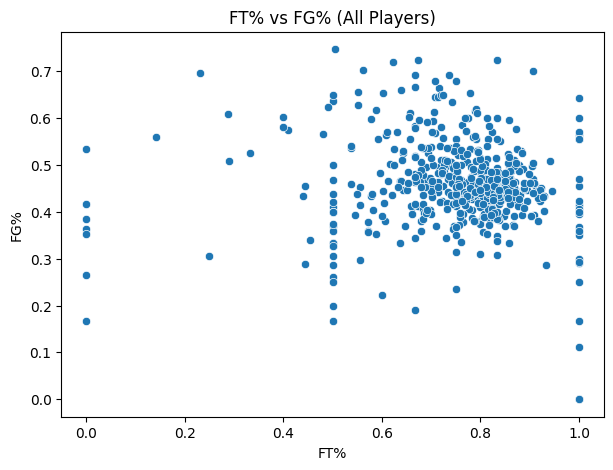

In [4]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=basketball, x="FT%", y="FG%")
plt.title("FT% vs FG% (All Players)")
plt.show()

There’s no strong pattern. The points are all over the place, so FT% doesn’t really predict FG%. They’re just different kinds of shots.

**Task2**:

Make a scatter plot with FT% on the horizontal axis and FG% on the vertical axis. Do this for each each Position in the data set.

Pay special attention to the plots for C and PF.

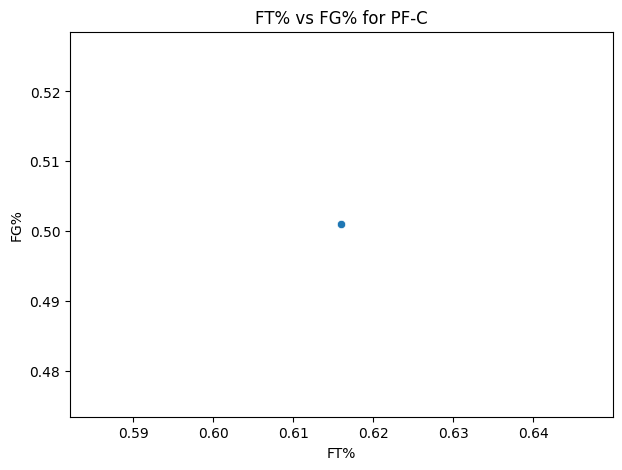

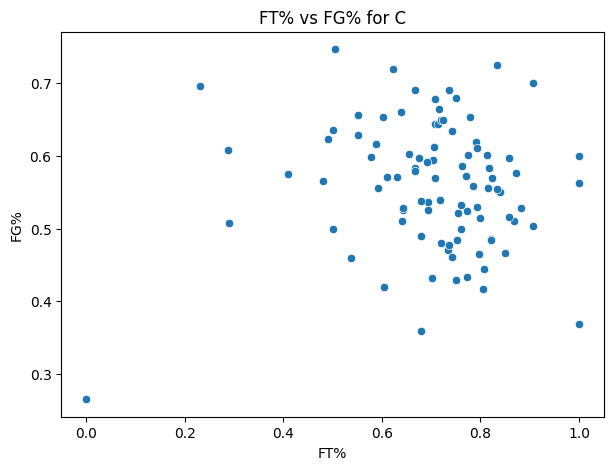

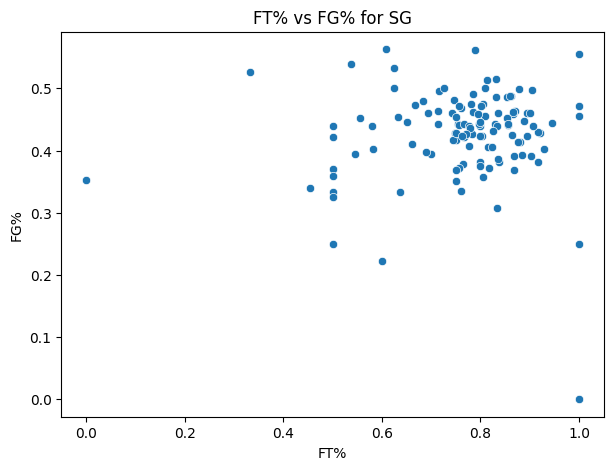

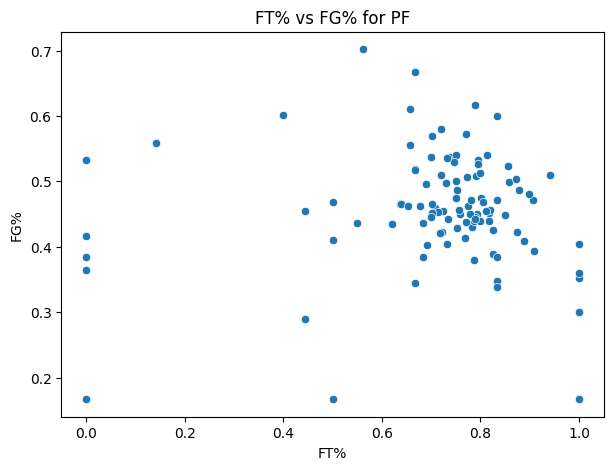

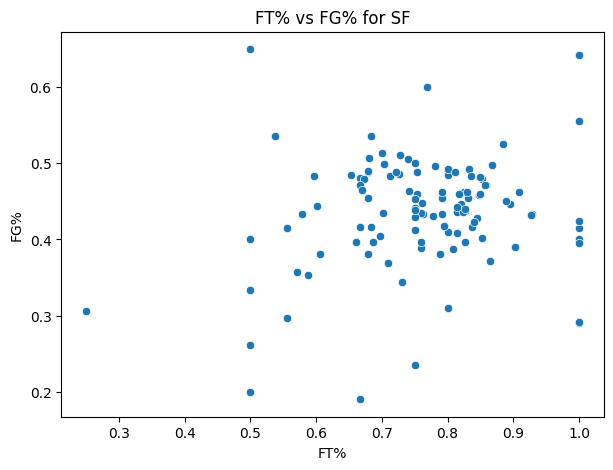

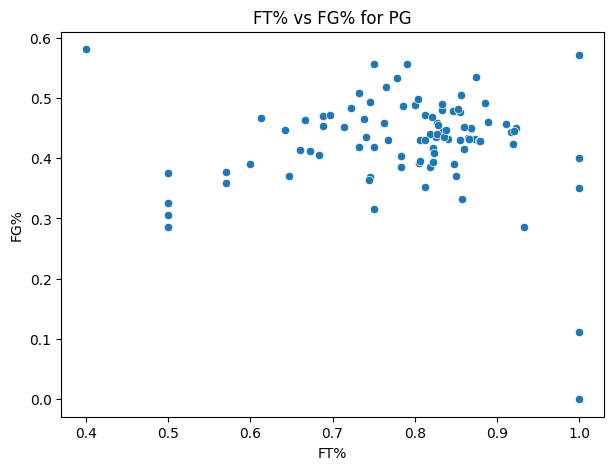

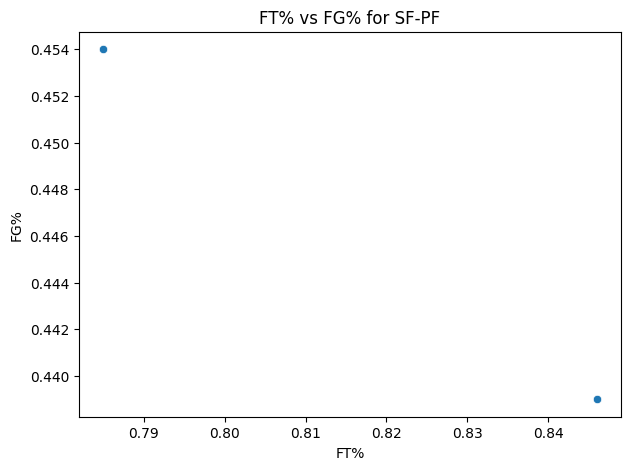

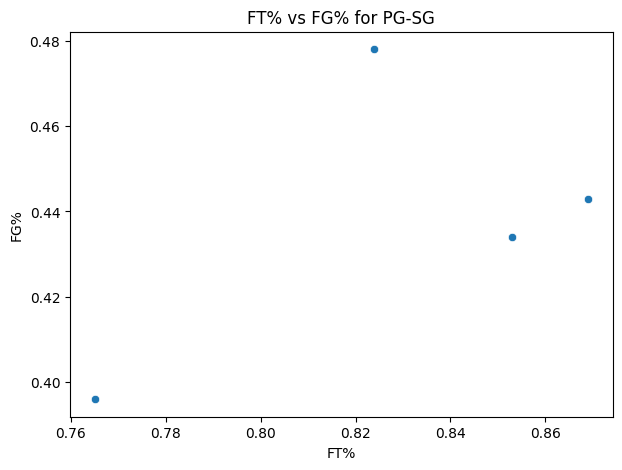

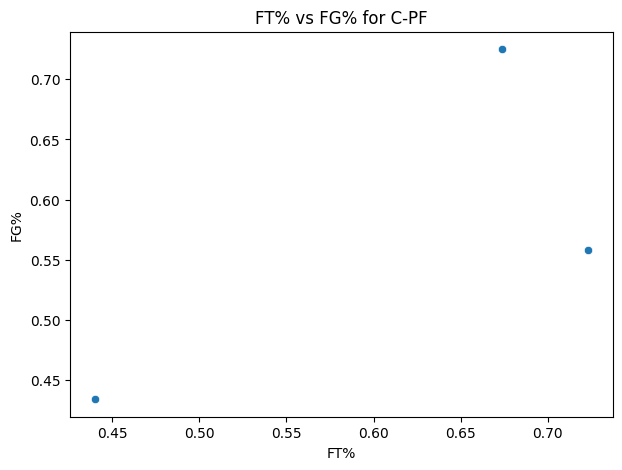

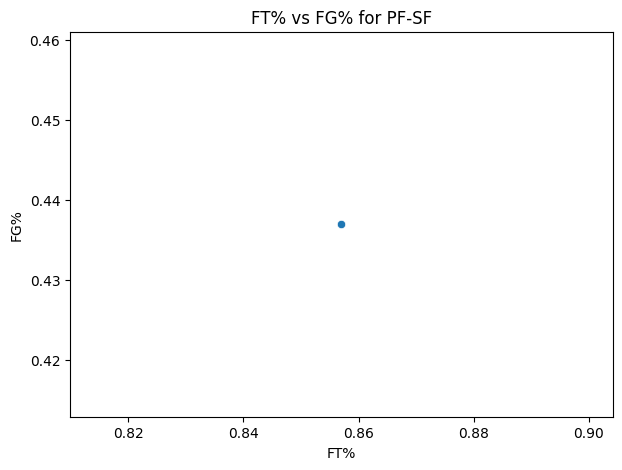

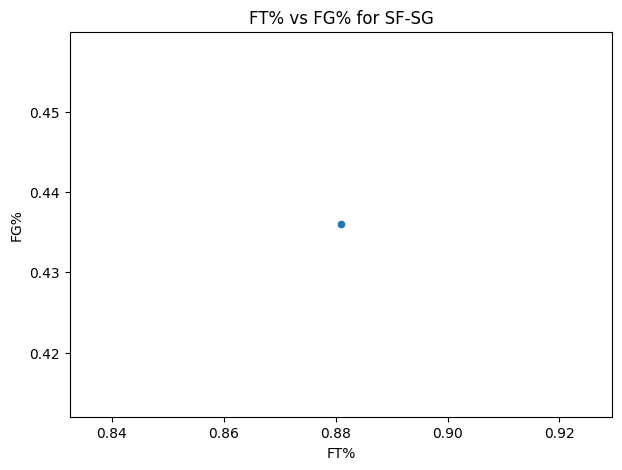

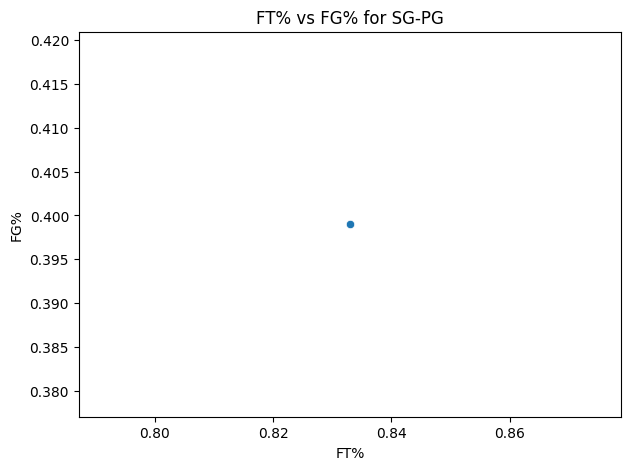

In [5]:
positions = basketball['Pos'].unique()
for p in positions:
    subset = basketball[basketball['Pos'] == p]
    plt.figure(figsize=(7,5))
    sns.scatterplot(data=subset, x="FT%", y="FG%")
    plt.title(f"FT% vs FG% for {p}")
    plt.show()

Once you split by position, the graphs make more sense. Centers shoot close shots, guards shoot more jumpers, etc. That’s why different positions form different clusters.

**Task3**:

Originally, I was going to get you to create and run an individual linear regression model for each of the positions.

But I couldn't even get model to run.

Explain why a linear regression model won't run on the full dataset. HInt: look at the graphs you made above, and compare and contrast them to the ones from class.

Or: if you do what I could not and get a linear regression model to run on the full data set, I'll give you full credit and a high five.

The relationship isn’t linear, there are weird outliers, and some players barely shoot free throws. All of that makes the regression unstable and it breaks.

## From Linear Model to Generalized Linear Model

You'll now fit a linear regression on the height and weight for people or the Kalahari !Kung San people. Height will be the predictor and weight will be the predicted.

Here's the raw data.

In [8]:
#downloads the data from my github
howell = pd.read_csv('https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/howell.csv')

In [9]:
howell

,height,weight,age,male
0,151.765,47.825606,63.0,1
1,139.700,36.485807,63.0,0
2,136.525,31.864838,65.0,0
3,156.845,53.041914,41.0,1
4,145.415,41.276872,51.0,0
...,...,...,...,...
539,145.415,31.127751,17.0,1
540,162.560,52.163080,31.0,1
541,156.210,54.062497,21.0,0
542,71.120,8.051258,0.0,1


**Task4**:

Make a scatter plot of height versus weight for the howell data set.

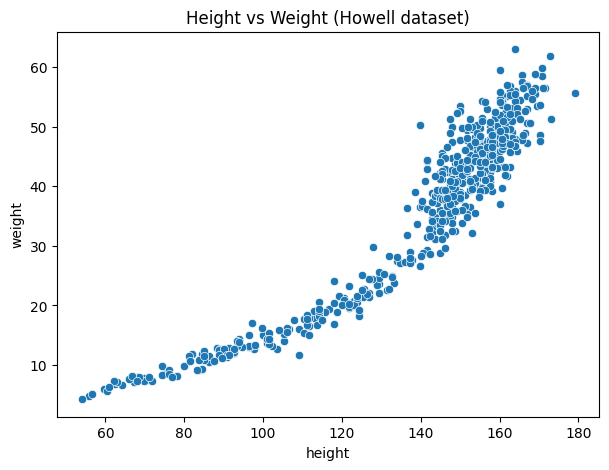

In [10]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=howell, x="height", y="weight")
plt.title("Height vs Weight (Howell dataset)")
plt.show()

This one actually looks clean. Taller people weigh more, and the points follow a clear upward trend.

**Task5**:

Create and run a stright line linear regression model on the howell data set with height predicting weight. Visualize your model and its posterior.

                            OLS Regression Results                            
Dep. Variable:                 weight   R-squared:                       0.885
Model:                            OLS   Adj. R-squared:                  0.885
Method:                 Least Squares   F-statistic:                     4177.
Date:                Fri, 05 Dec 2025   Prob (F-statistic):          7.25e-257
Time:                        19:29:51   Log-Likelihood:                -1645.7
No. Observations:                 544   AIC:                             3295.
Df Residuals:                     542   BIC:                             3304.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -33.7561      1.094    -30.844      0.0

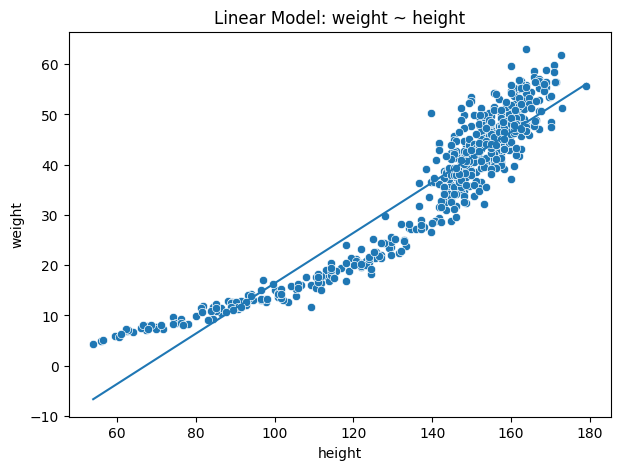

In [16]:
X = sm.add_constant(howell["height"])
y = howell["weight"]

lin_model = sm.OLS(y, X).fit()
print(lin_model.summary())

height_seq = np.linspace(howell["height"].min(), howell["height"].max(), 200)
pred_line = lin_model.params["const"] + lin_model.params["height"] * height_seq

plt.figure(figsize=(7,5))
sns.scatterplot(data=howell, x="height", y="weight")
plt.plot(height_seq, pred_line)
plt.title("Linear Model: weight ~ height")
plt.show()


The line fits the overall pattern, but heavier people vary more, so the model isn’t perfect.

I did some reading and found a Python library that made this a bit easier for me (statsmodels.org).

**Task6**:

Run a posterior predictive check for model_howell, plot the posterior predictive distribution, and comment on the fit of the model you made in Task5.

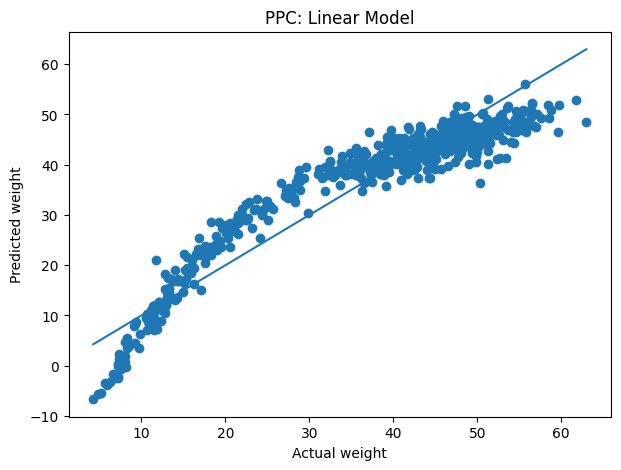

In [17]:
pred_lin = lin_model.predict(sm.add_constant(howell["height"]))

plt.figure(figsize=(7,5))
plt.scatter(howell["weight"], pred_lin)
plt.xlabel("Actual weight")
plt.ylabel("Predicted weight")
plt.title("PPC: Linear Model")
plt.plot([howell["weight"].min(), howell["weight"].max()],
         [howell["weight"].min(), howell["weight"].max()])
plt.show()

Predicted vs actual is mostly close to the diagonal, but the model struggles more for heavier people. Not terrible, but not great.

**Task7**:

Create and visualize the posterior of a generalized linear model that improves the on the fit of the model you made in Task5.

                 Generalized Linear Model Regression Results                  
Dep. Variable:                 weight   No. Observations:                  544
Model:                            GLM   Df Residuals:                      542
Model Family:                   Gamma   Df Model:                            1
Link Function:                    log   Scale:                        0.011917
Method:                          IRLS   Log-Likelihood:                -1432.4
Date:                Fri, 05 Dec 2025   Deviance:                       6.2986
Time:                        19:31:18   Pearson chi2:                     6.46
No. Iterations:                     8   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6120      0.024     25.577      0.0

/usr/local/lib/python3.12/dist-packages/statsmodels/genmod/families/links.py:13: FutureWarning: The log link alias is deprecated. Use Log instead. The log link alias will be removed after the 0.15.0 release.
  warnings.warn(


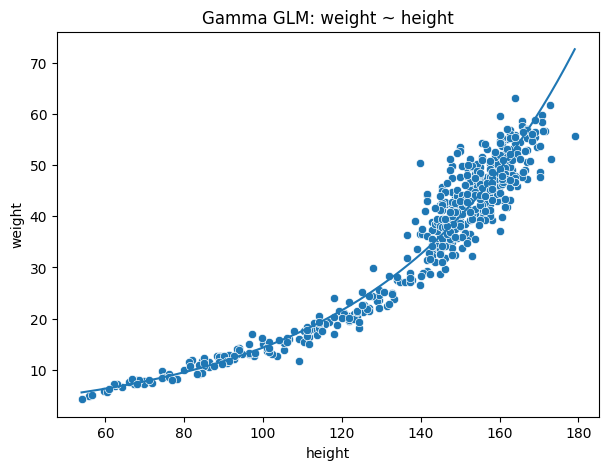

In [18]:
X = sm.add_constant(howell["height"])
y = howell["weight"]

glm_model = sm.GLM(
    y,
    X,
    family=sm.families.Gamma(link=sm.families.links.log())
).fit()

print(glm_model.summary())

# Plot GLM curve
pred_glm_curve = glm_model.predict(sm.add_constant(height_seq))

plt.figure(figsize=(7,5))
sns.scatterplot(data=howell, x="height", y="weight")
plt.plot(height_seq, pred_glm_curve)
plt.title("Gamma GLM: weight ~ height")
plt.show()


This model fits better because weight is positive and the spread increases with height. The curve matches the data more naturally.

**Task8**:

Run a posterior predictive check, and visualize the posterior predictive distribution, for the model you made in Task7.

Comment on the fit.

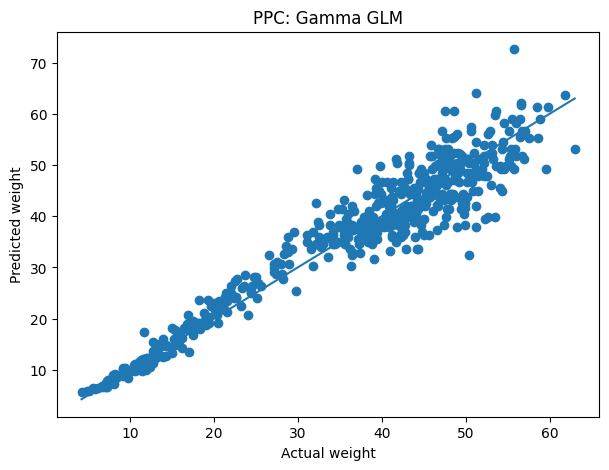

In [19]:
pred_glm = glm_model.predict(sm.add_constant(howell["height"]))

plt.figure(figsize=(7,5))
plt.scatter(howell["weight"], pred_glm)
plt.xlabel("Actual weight")
plt.ylabel("Predicted weight")
plt.title("PPC: Gamma GLM")
plt.plot([howell["weight"].min(), howell["weight"].max()],
         [howell["weight"].min(), howell["weight"].max()])
plt.show()

The predictions line up with the diagonal better than the linear model’s. The GLM handles the data more accurately overall.